In [ ]:
Inicialmente, os dados foram retirados do seguinte dataset https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce?utm_source=ch

In [ ]:
Após a verificação inicial dos dados, foram levantadas as seguintes questões:

Qual estado possui mais clientes?
Qual categoria vende mais?
Qual vendedor faturou mais?
Qual é o ticket médio?
Qual forma de pagamento é mais utilizada?
Qual mês teve maior faturamento?

In [1]:
import pandas as pd

In [2]:
#1- Importando arquivos e bases de dados
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_order_items = pd.read_csv('olist_order_items_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')
df_category_translation = pd.read_csv('product_category_name_translation.csv')
df_sellers = pd.read_csv('olist_sellers_dataset.csv')
df_payments = pd.read_csv('olist_order_payments_dataset.csv')

In [5]:
#Qual estado possui mais clientes?
df_customers['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [8]:
#Para responder (Qual categoria vende mais) e preciso juntar tabelas
df_merged = df_order_items.merge(df_products, on='product_id', how='left')

In [9]:
#Qual categoria vende mais? lado a lado
df_merged = df_merged[['product_category_name','price']]
print(df_merged.head())

  product_category_name   price
0            cool_stuff   58.90
1              pet_shop  239.90
2      moveis_decoracao  199.00
3            perfumaria   12.99
4    ferramentas_jardim  199.90


In [11]:
#Qual categoria vende mais?
df_merged['product_category_name'].value_counts().head(10)

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64

In [15]:
#Qual vendedor faturou mais?
faturamento_vendedores = df_merged.groupby('seller_id')['price'].sum().sort_values(ascending=False)
faturamento_vendedores.head(5)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
Name: price, dtype: float64

In [16]:
#Qual é o ticket médio?
valor_por_pedido = df_payments.groupby('order_id')['payment_value'].sum()
ticket_medio = valor_por_pedido.mean()
print(f"Ticket médio: R$ {ticket_medio:.2f}")

Ticket médio: R$ 160.99


In [17]:
#Qual forma de pagamento é mais utilizada?
formas_pagamento = df_payments['payment_type'].value_counts()
formas_pagamento

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [23]:
#faturamento por mes e ano
faturamento_mensal = df_faturamento.groupby('mes_ano')['payment_value'].sum()
faturamento_mensal

mes_ano
2016-09        252.24
2016-10      59090.48
2016-12         19.62
2017-01     138488.04
2017-02     291908.01
2017-03     449863.60
2017-04     417788.03
2017-05     592918.82
2017-06     511276.38
2017-07     592382.92
2017-08     674396.32
2017-09     727762.45
2017-10     779677.88
2017-11    1194882.80
2017-12     878401.48
2018-01    1115004.18
2018-02     992463.34
2018-03    1159652.12
2018-04    1160785.48
2018-05    1153982.15
2018-06    1023880.50
2018-07    1066540.75
2018-08    1022425.32
2018-09       4439.54
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64

In [26]:
import matplotlib.pyplot as plt

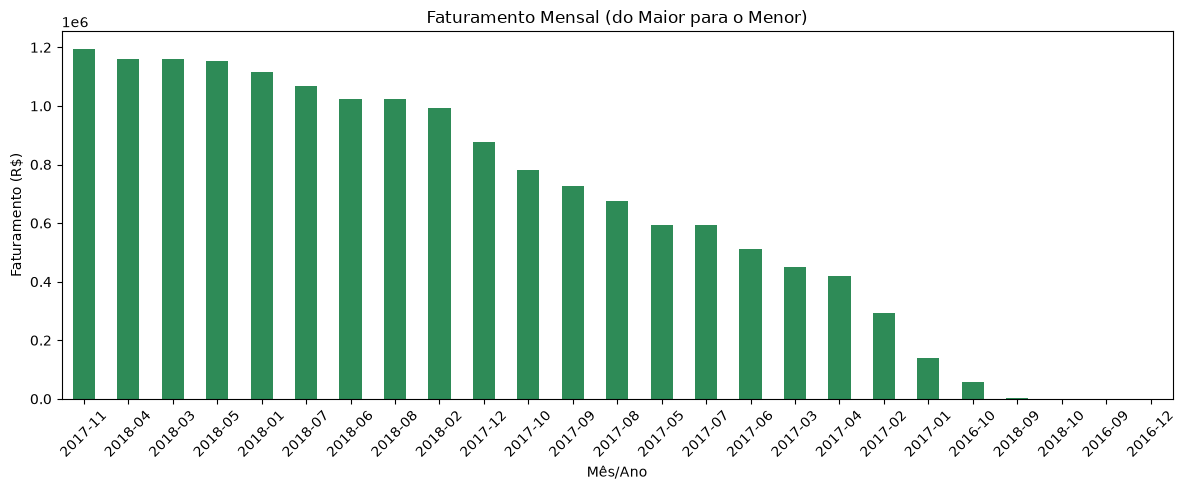

In [27]:
#Qual mês teve maior faturamento?
faturamento_mensal_ordenado = faturamento_mensal.sort_values(ascending=False)
faturamento_mensal_ordenado.index = faturamento_mensal_ordenado.index.astype(str)

plt.figure(figsize=(12, 5))
faturamento_mensal_ordenado.plot(kind='bar', color='seagreen')
plt.title('Faturamento Mensal (do Maior para o Menor)')
plt.xlabel('Mês/Ano')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()